# Team B — Sprint 1 Spatial Data Analysis Pipeline

**Project:** Urban Streetscape Intervention Analysis (USIA)  
**Team:** Team B — Traffic Volumes & Parking  
**Prepared by:** Tamil Elakkiya Ganapathi  
**Sprint:** Sprint 1  
**Research question:** How does parking use change after bike lanes are constructed?

## Purpose of this notebook
This notebook:
1. Loads the three spatial datasets supplied by Infrastructure Victoria.
2. Checks their structure, geometry and data quality.
3. Validates the spatial join keys.
4. Integrates street attributes with buffered study areas.
5. Creates treatment/control, Melbourne and regional maps.
6. Identifies protected bike-lane locations outside the CBD for Team B.
7. Exports reusable tables and spatial outputs for later parking and traffic analysis.

> **Scope note:** These datasets define the study locations and boundaries. They do not contain parking occupancy observations or intervention dates, so parking utilisation and before/after effects cannot yet be calculated.

This notebook complements the Team B dataset inventory by implementing a reusable Python workflow for analysing the Infrastructure Victoria spatial datasets. The outputs generated here are intended to support the integration of future datasets such as SCATS traffic volumes, parking occupancy records and aerial imagery.


## 1. Install and import packages

In [1]:
!pip -q install geopandas pyogrio contextily mapclassify

In [2]:
import os
import zipfile
import warnings

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("GeoPandas version:", gpd.__version__)

GeoPandas version: 1.1.4


## 2. Upload the project ZIP file


In [3]:
from google.colab import files

uploaded = files.upload()
zip_names = [name for name in uploaded if name.lower().endswith(".zip")]

if not zip_names:
    raise FileNotFoundError("Please upload the ZIP file containing all spatial files.")

zip_name = zip_names[0]
data_dir = "/content/usia_data"
os.makedirs(data_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as archive:
    archive.extractall(data_dir)

print("Files extracted to:", data_dir)
for root, _, filenames in os.walk(data_dir):
    for filename in filenames:
        print(os.path.join(root, filename))

Saving USIA_Spatial_Data.zip to USIA_Spatial_Data.zip
Files extracted to: /content/usia_data
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.prj
/content/usia_data/USIA_Spatial_Data/street_spatial_study_area.gpkg
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.qix
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.shp
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.cpg
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.dbf
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.qmd
/content/usia_data/USIA_Spatial_Data/road_segments_15dec.shx
/content/usia_data/USIA_Spatial_Data/streets_spatial.gpkg


## 3. Locate and load the spatial files

In [4]:
def find_file(root_folder, expected_names):
    expected_names = {name.lower() for name in expected_names}
    for root, _, filenames in os.walk(root_folder):
        for filename in filenames:
            if filename.lower() in expected_names:
                return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find any of: {sorted(expected_names)}")

street_path = find_file(
    data_dir,
    ["streets_spatial.gpkg", "street_spatial.gpkg"]
)
study_area_path = find_file(
    data_dir,
    ["street_spatial_study_area.gpkg"]
)
road_path = find_file(
    data_dir,
    ["road_segments_15dec.shp"]
)

streets = gpd.read_file(street_path)
study_areas = gpd.read_file(study_area_path)
roads = gpd.read_file(road_path)

print("Streets:", streets.shape, streets.crs)
print("Study areas:", study_areas.shape, study_areas.crs)
print("Road network:", roads.shape, roads.crs)

Streets: (315, 11) EPSG:7899
Study areas: (316, 2) EPSG:7899
Road network: (12035, 8) EPSG:7855


## 4. Preview the datasets

In [5]:
display(streets.head())
display(study_areas.head())
display(roads.head())

,street_name,street_segment_id,suburb,postcode,lga,treatment_or_control,intervention_type,cbd,metro,regional,geometry
0,KEILOR ROAD,211.0,Essendon,3040,Moonee Valley (C),control,control,0.0,1.0,0.0,"LINESTRING (2491114.443 2417873.878, 2491077.3..."
1,KEILOR ROAD,212.0,Niddrie,3042,Moonee Valley (C),control,control,0.0,1.0,0.0,"LINESTRING (2490510.786 2418174.272, 2490453.5..."
2,VICTORIA AVENUE,224.0,Albert Park,3206,Port Phillip (C),control,control,0.0,1.0,0.0,"LINESTRING (2495452.168 2405934.307, 2495484.1..."
3,MALING ROAD,269.0,Canterbury,3126,Boroondara (C),control,control,0.0,1.0,0.0,"LINESTRING (2507070.632 2408393.017, 2507081.7..."
4,STEPHENSONS ROAD,300.0,Mount Waverley,3149,Monash (C),control,control,0.0,1.0,0.0,"LINESTRING (2511307.487 2402518.689, 2511325.0..."


,street_segment_id,geometry
0,123,"MULTIPOLYGON (((2443617.078 2372579.175, 24439..."
1,124,"MULTIPOLYGON (((2443767.066 2372271.314, 24437..."
2,125,"MULTIPOLYGON (((2443774.896 2371912.566, 24437..."
3,858,"MULTIPOLYGON (((2497567.245 2410842.519, 24975..."
4,859,"MULTIPOLYGON (((2497512.826 2410438.772, 24975..."


,fid,road_name,location,ROAD_TYPE,CLASS_CODE,length_km,street_seg,geometry
0,1.0,FERNHILL ROAD,Middle Melbourne,ROAD,4.0,0.727,1,"LINESTRING (324977.993 5797611.82, 325062.441 ..."
1,2.0,MILL ROAD,regional City,ROAD,4.0,1.722,2,"LINESTRING (272835.041 5788500.981, 272856.997..."
2,3.0,REYNARD STREET,Inner Melbourne,STREET,4.0,1.856,3,"LINESTRING (320744.199 5820132.378, 320724.417..."
3,4.0,REYNARD STREET,Middle Melbourne,STREET,3.0,0.529,4,"LINESTRING (318898.811 5820318.886, 318804.885..."
4,5.0,REYNARD STREET,Middle Melbourne,STREET,3.0,0.479,5,"LINESTRING (318374.517 5820388.007, 318368.473..."


In [6]:
print("Street columns:")
print(streets.columns.tolist())

print("\nStudy-area columns:")
print(study_areas.columns.tolist())

print("\nRoad-network columns:")
print(roads.columns.tolist())

Street columns:
['street_name', 'street_segment_id', 'suburb', 'postcode', 'lga', 'treatment_or_control', 'intervention_type', 'cbd', 'metro', 'regional', 'geometry']

Study-area columns:
['street_segment_id', 'geometry']

Road-network columns:
['fid', 'road_name', 'location', 'ROAD_TYPE', 'CLASS_CODE', 'length_km', 'street_seg', 'geometry']


## 5. Basic data-quality checks

In [7]:
def quality_report(gdf, dataset_name):
    return pd.DataFrame({
        "dataset": [dataset_name],
        "rows": [len(gdf)],
        "columns": [len(gdf.columns)],
        "missing_cells": [int(gdf.isna().sum().sum())],
        "duplicate_rows_without_geometry": [
            int(gdf.drop(columns="geometry", errors="ignore").duplicated().sum())
        ],
        "empty_geometries": [int(gdf.geometry.is_empty.sum())],
        "missing_geometries": [int(gdf.geometry.isna().sum())],
        "invalid_geometries": [int((~gdf.geometry.is_valid).sum())],
        "crs": [str(gdf.crs)],
    })

quality_summary = pd.concat([
    quality_report(streets, "streets_spatial"),
    quality_report(study_areas, "street_spatial_study_area"),
    quality_report(roads, "road_segments_15dec"),
], ignore_index=True)

display(quality_summary)

,dataset,rows,columns,missing_cells,duplicate_rows_without_geometry,empty_geometries,missing_geometries,invalid_geometries,crs
0,streets_spatial,315,11,0,0,0,0,0,EPSG:7899
1,street_spatial_study_area,316,2,0,0,0,0,0,EPSG:7899
2,road_segments_15dec,12035,8,5185,0,0,0,0,EPSG:7855


## 6. Check the main street dataset


In [8]:
print("Number of street rows:", len(streets))
print("Unique street_segment_id values:", streets["street_segment_id"].nunique())
print("Duplicate street_segment_id values:", streets["street_segment_id"].duplicated().sum())

print("\nTreatment/control counts:")
display(streets["treatment_or_control"].value_counts(dropna=False).rename_axis("category").reset_index(name="count"))

print("\nIntervention type counts:")
display(streets["intervention_type"].value_counts(dropna=False).rename_axis("intervention_type").reset_index(name="count"))

Number of street rows: 315
Unique street_segment_id values: 315
Duplicate street_segment_id values: 0

Treatment/control counts:


,category,count
0,control,219
1,treatment,96



Intervention type counts:


,intervention_type,count
0,control,219
1,protected bike lane,80
2,regional_reallocation,10
3,pedestrian,6


In [9]:
location_summary = pd.DataFrame({
    "location_group": ["CBD", "Metro", "Regional"],
    "street_segments": [
        int(streets["cbd"].sum()),
        int(streets["metro"].sum()),
        int(streets["regional"].sum())
    ]
})

display(location_summary)

,location_group,street_segments
0,CBD,39
1,Metro,242
2,Regional,34


## 7. Validate joins between datasets

The metadata states:

- `streets.street_segment_id` joins to `study_areas.street_segment_id`
- `streets.street_segment_id` joins to `roads.street_seg`

In [10]:
# Standardise key types before comparing or joining.
streets["street_segment_id"] = pd.to_numeric(
    streets["street_segment_id"], errors="coerce"
).astype("Int64")

study_areas["street_segment_id"] = pd.to_numeric(
    study_areas["street_segment_id"], errors="coerce"
).astype("Int64")

roads["street_seg"] = pd.to_numeric(
    roads["street_seg"], errors="coerce"
).astype("Int64")

print("Street key type:", streets["street_segment_id"].dtype)
print("Study-area key type:", study_areas["street_segment_id"].dtype)
print("Road key type:", roads["street_seg"].dtype)

Street key type: Int64
Study-area key type: Int64
Road key type: Int64


## 8. Join street attributes to buffered study areas

The result is a polygon dataset containing the treatment/control and intervention attributes.

In [11]:
street_attributes = streets.drop(columns="geometry").copy()

study_areas_enriched = study_areas.merge(
    street_attributes,
    on="street_segment_id",
    how="left",
    validate="many_to_one"
)

print("Joined study-area shape:", study_areas_enriched.shape)

matched_rows = study_areas_enriched["treatment_or_control"].notna().sum()
unmatched_rows = study_areas_enriched["treatment_or_control"].isna().sum()

print("Matched rows:", matched_rows)
print("Unmatched rows:", unmatched_rows)

display(
    study_areas_enriched[
        [
            "street_segment_id",
            "street_name",
            "treatment_or_control",
            "intervention_type"
        ]
    ].head()
)

Joined study-area shape: (316, 11)
Matched rows: 315
Unmatched rows: 1


,street_segment_id,street_name,treatment_or_control,intervention_type
0,123,GHERINGHAP STREET,treatment,protected bike lane
1,124,GHERINGHAP STREET,treatment,protected bike lane
2,125,GHERINGHAP STREET,treatment,protected bike lane
3,858,RATHDOWNE STREET,treatment,protected bike lane
4,859,RATHDOWNE STREET,treatment,protected bike lane


In [12]:
unmatched_records = study_areas_enriched[
    study_areas_enriched["treatment_or_control"].isna()
].copy()

display(
    unmatched_records[
        [
            "street_segment_id",
            "geometry"
        ]
    ]
)

,street_segment_id,geometry
20,3500,"MULTIPOLYGON (((2670080.486 2595517.465, 26697..."


In [13]:
unmatched_id = unmatched_records["street_segment_id"].tolist()

print("Unmatched street segment ID:", unmatched_id)

print(
    "Does this ID exist in the streets dataset?",
    streets["street_segment_id"].isin(unmatched_id).any()
)

print(
    "Does this ID exist in the road network?",
    roads["street_seg"].isin(unmatched_id).any()
)

Unmatched street segment ID: [3500]
Does this ID exist in the streets dataset? False
Does this ID exist in the road network? True


### Join validation finding

One buffered study-area record with `street_segment_id = 3500` did not match the main `streets_spatial` treatment/control dataset. The same segment exists in the wider road-network dataset. Therefore, this record was retained in the joined dataset but excluded from treatment/control visualisations because intervention attributes were unavailable.

## 9. Create spatial maps

The spatial layers are reprojected to EPSG:3857 for consistent plotting. One unmatched buffered record is excluded only from treatment/control visualisations because it has no treatment/control attributes.


In [14]:
# Create projected datasets for mapping
streets_web = streets.to_crs(epsg=3857)
study_web = study_areas_enriched.to_crs(epsg=3857)
roads_web = roads.to_crs(epsg=3857)

print(study_web["treatment_or_control"].value_counts(dropna=False))

treatment_or_control
control      219
treatment     96
NaN            1
Name: count, dtype: int64


Total study-area rows: 316
Rows used for map: 315
Rows excluded as unmatched: 1


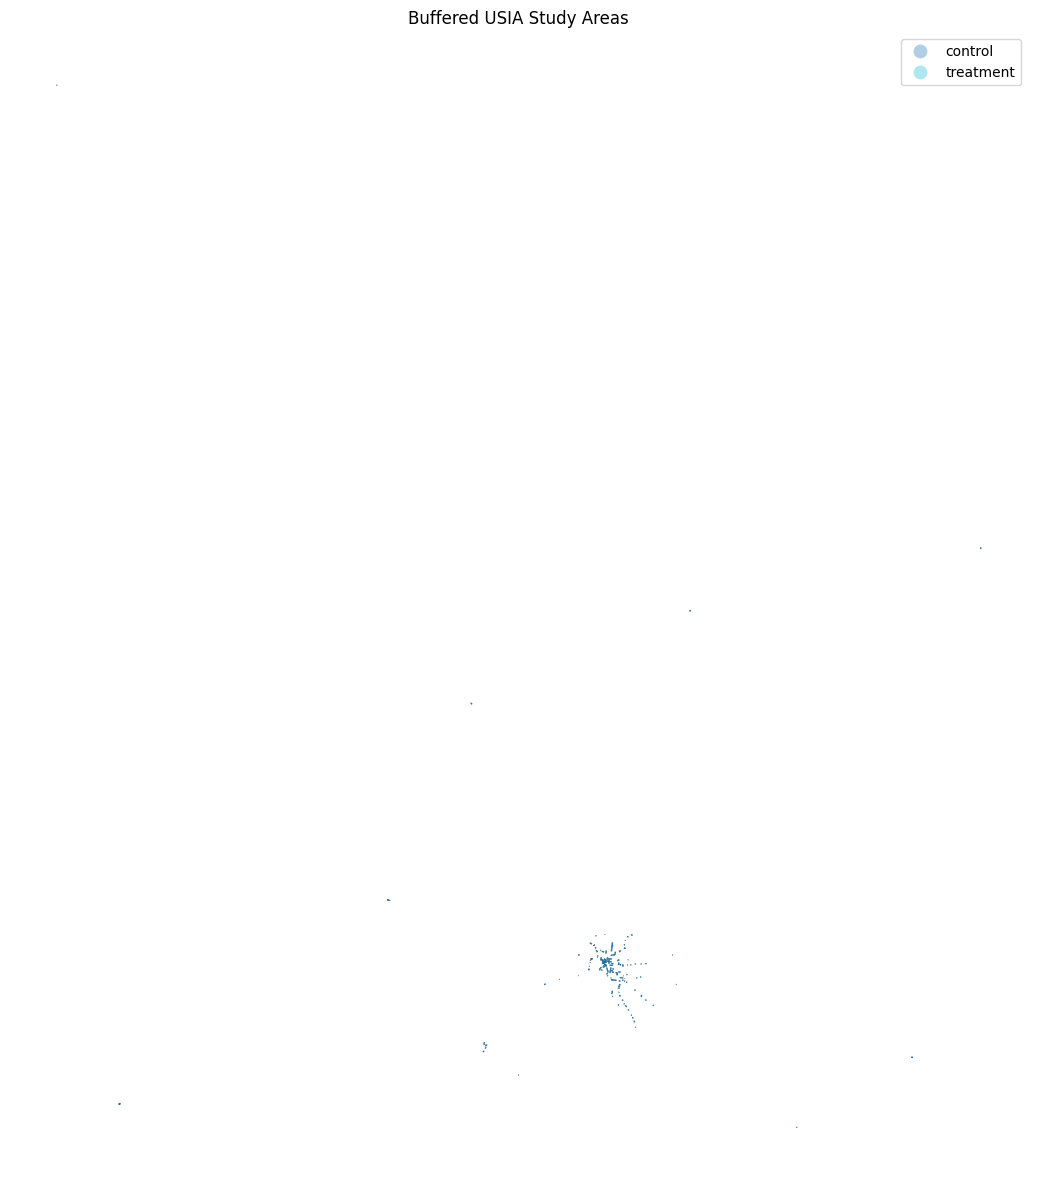

In [15]:
study_web_plot = study_web.dropna(
    subset=["treatment_or_control", "geometry"]
).copy()

print("Total study-area rows:", len(study_web))
print("Rows used for map:", len(study_web_plot))
print("Rows excluded as unmatched:", len(study_web) - len(study_web_plot))

fig, ax = plt.subplots(figsize=(12, 12))

study_web_plot.plot(
    ax=ax,
    column="treatment_or_control",
    categorical=True,
    legend=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.25
)

streets_web.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title("Buffered USIA Study Areas")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Melbourne study-area records: 281


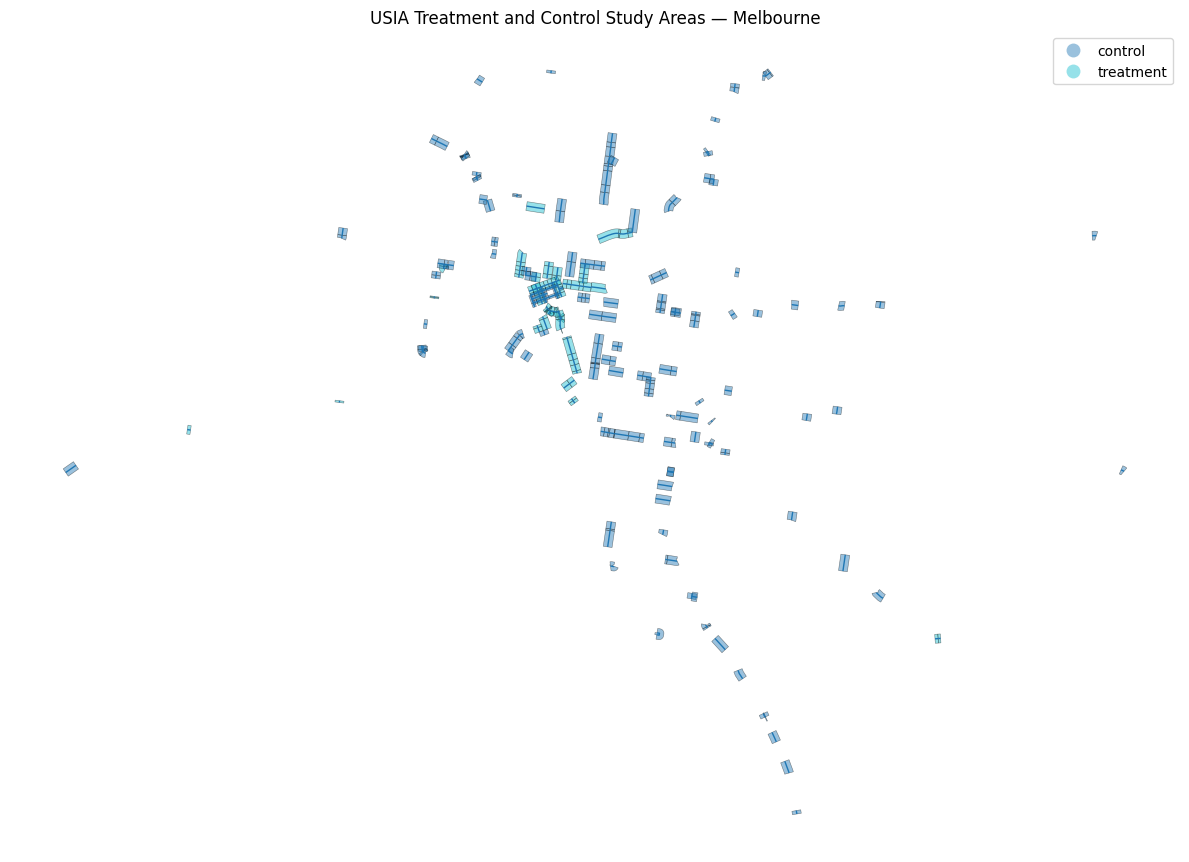

In [16]:
# Filter to Melbourne CBD and metropolitan study areas
melbourne_study = study_web_plot[
    (study_web_plot["metro"] == 1) |
    (study_web_plot["cbd"] == 1)
].copy()

melbourne_streets = streets_web[
    (streets_web["metro"] == 1) |
    (streets_web["cbd"] == 1)
].copy()

print("Melbourne study-area records:", len(melbourne_study))

fig, ax = plt.subplots(figsize=(12, 12))

melbourne_study.plot(
    ax=ax,
    column="treatment_or_control",
    categorical=True,
    legend=True,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.4
)

melbourne_streets.plot(
    ax=ax,
    linewidth=1.0
)

ax.set_title("USIA Treatment and Control Study Areas — Melbourne")
ax.set_axis_off()

plt.tight_layout()
plt.show()

Regional study-area records: 34


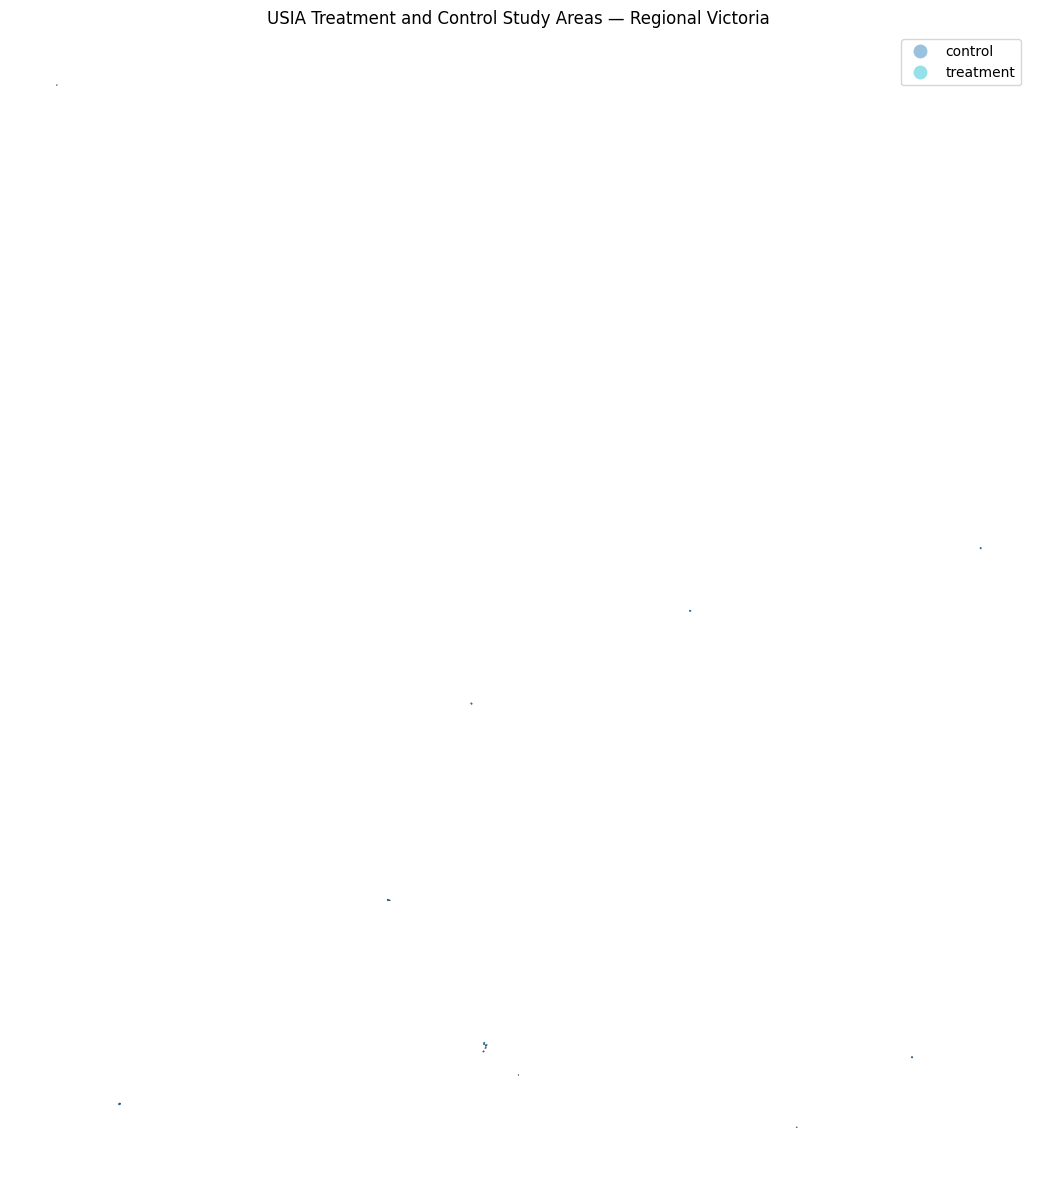

In [17]:
regional_study = study_web_plot[
    study_web_plot["regional"] == 1
].copy()

regional_streets = streets_web[
    streets_web["regional"] == 1
].copy()

print("Regional study-area records:", len(regional_study))

fig, ax = plt.subplots(figsize=(12, 12))

regional_study.plot(
    ax=ax,
    column="treatment_or_control",
    categorical=True,
    legend=True,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.4
)

regional_streets.plot(
    ax=ax,
    linewidth=1.0
)

ax.set_title("USIA Treatment and Control Study Areas — Regional Victoria")
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 10. Create summary tables


In [18]:
treatment_summary = (
    streets.groupby(["treatment_or_control", "intervention_type"], dropna=False)
    .size()
    .reset_index(name="street_segments")
    .sort_values("street_segments", ascending=False)
)

suburb_summary = (
    streets.groupby(["suburb", "treatment_or_control"], dropna=False)
    .size()
    .reset_index(name="street_segments")
    .sort_values("street_segments", ascending=False)
)

lga_summary = (
    streets.groupby(["lga", "treatment_or_control"], dropna=False)
    .size()
    .reset_index(name="street_segments")
    .sort_values("street_segments", ascending=False)
)

display(treatment_summary)
display(suburb_summary.head(20))
display(lga_summary.head(20))

,treatment_or_control,intervention_type,street_segments
0,control,control,219
2,treatment,protected bike lane,80
3,treatment,regional_reallocation,10
1,treatment,pedestrian,6


,suburb,treatment_or_control,street_segments
69,Melbourne,treatment,28
68,Melbourne,control,22
103,Southbank,treatment,12
55,Hawthorn,control,8
39,Essendon,control,8
90,Prahran,control,7
91,Preston,control,7
38,Elsternwick,control,6
65,Malvern,control,6
36,East Melbourne,treatment,5


,lga,treatment_or_control,street_segments
22,Melbourne (C),treatment,51
21,Melbourne (C),control,32
31,Stonnington (C),control,25
4,Boroondara (C),control,20
8,Glen Eira (C),control,19
17,Kingston (C) (Vic.),control,13
2,Banyule (C),control,13
29,Port Phillip (C),treatment,13
27,Moonee Valley (C),control,13
6,Darebin (C),control,11


## 11. Create non-spatial charts


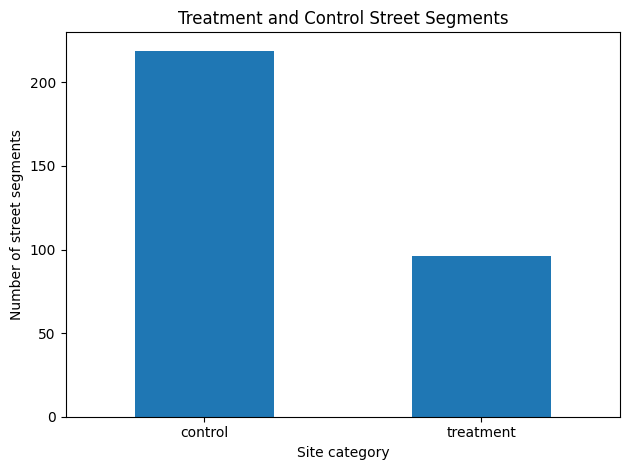

In [19]:
ax = streets["treatment_or_control"].value_counts().plot(
    kind="bar",
    title="Treatment and Control Street Segments"
)
ax.set_xlabel("Site category")
ax.set_ylabel("Number of street segments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

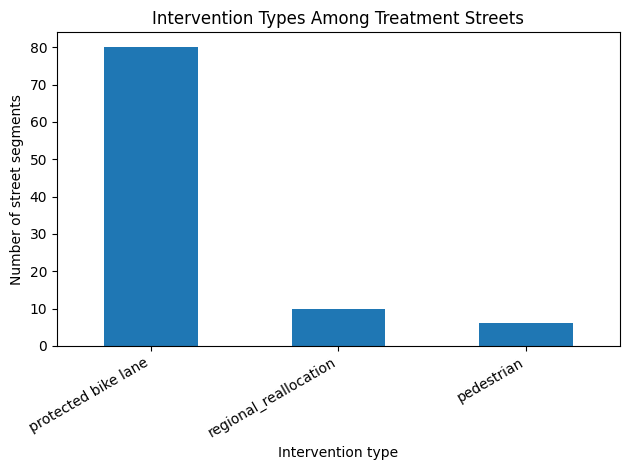

In [20]:
treatment_only = streets[
    streets["treatment_or_control"].str.lower().eq("treatment")
]

ax = treatment_only["intervention_type"].value_counts().plot(
    kind="bar",
    title="Intervention Types Among Treatment Streets"
)
ax.set_xlabel("Intervention type")
ax.set_ylabel("Number of street segments")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 12. Prepare a Team B priority subset

The Product Owner prioritised protected bike lanes and sites outside the CBD. This subset shortlists candidate segments for later parking-utilisation and traffic-volume analysis. Final study-site selection should be agreed by Team B.


In [21]:
team_b_priority = streets[
    streets["intervention_type"].str.lower().eq("protected bike lane")
    & streets["cbd"].eq(0)
].copy()

priority_columns = [
    "street_segment_id",
    "street_name",
    "suburb",
    "postcode",
    "lga",
    "treatment_or_control",
    "intervention_type",
    "cbd",
    "metro",
    "regional"
]

priority_table = team_b_priority[priority_columns].sort_values(
    ["suburb", "street_name", "street_segment_id"]
)

print("Priority protected bike-lane segments outside the CBD:", len(priority_table))
display(priority_table.head(30))

Priority protected bike-lane segments outside the CBD: 64


,street_segment_id,street_name,suburb,postcode,lga,treatment_or_control,intervention_type,cbd,metro,regional
266,7658,DAWSON STREET,Brunswick,3056,Merri-Bek (C),treatment,protected bike lane,0.0,1.0,0.0
207,858,RATHDOWNE STREET,Carlton,3053,Melbourne (C),treatment,protected bike lane,0.0,1.0,0.0
208,859,RATHDOWNE STREET,Carlton,3053,Melbourne (C),treatment,protected bike lane,0.0,1.0,0.0
279,10529,SWANSTON STREET,Carlton,3053,Melbourne (C),treatment,protected bike lane,0.0,1.0,0.0
280,10530,SWANSTON STREET,Carlton,3053,Melbourne (C),treatment,protected bike lane,0.0,1.0,0.0
281,10531,SWANSTON STREET,Carlton,3053,Melbourne (C),treatment,protected bike lane,0.0,1.0,0.0
269,8218,HEIDELBERG ROAD,Clifton Hill,3068,Yarra (C),treatment,protected bike lane,0.0,1.0,0.0
246,5881,WELLINGTON STREET,Collingwood,3066,Yarra (C),treatment,protected bike lane,0.0,1.0,0.0
247,5882,WELLINGTON STREET,Collingwood,3066,Yarra (C),treatment,protected bike lane,0.0,1.0,0.0
248,5883,WELLINGTON STREET,Collingwood,3066,Yarra (C),treatment,protected bike lane,0.0,1.0,0.0


## 13. Examine missing attributes in the wider road network

The wider road network is a contextual reference layer. This analysis identifies which attributes account for its missing cells.


In [22]:
road_missing_summary = (
    roads.isna()
    .sum()
    .reset_index()
)

road_missing_summary.columns = [
    "column",
    "missing_values"
]

road_missing_summary["missing_percentage"] = (
    road_missing_summary["missing_values"]
    / len(roads)
    * 100
).round(2)

display(
    road_missing_summary[
        road_missing_summary["missing_values"] > 0
    ].sort_values(
        "missing_values",
        ascending=False
    )
)

,column,missing_values,missing_percentage
5,length_km,4848,40.28
3,ROAD_TYPE,235,1.95
4,CLASS_CODE,101,0.84
2,location,1,0.01


### Road-network data-quality finding

The road-network dataset contains **12,035 road segments**. Missing values are concentrated in:

- `length_km`: **4,848 records (40.28%)**
- `ROAD_TYPE`: **235 records (1.95%)**
- `CLASS_CODE`: **101 records (0.84%)**
- `location`: **1 record (0.01%)**

No duplicate rows, missing geometries or invalid geometries were identified. Because this layer is used mainly for geographic context in Sprint 1, these missing descriptive attributes do not affect the completed treatment/control join. The missing `length_km` values should be addressed before any analysis that depends on road length.


## 14. Additional geographic summary charts


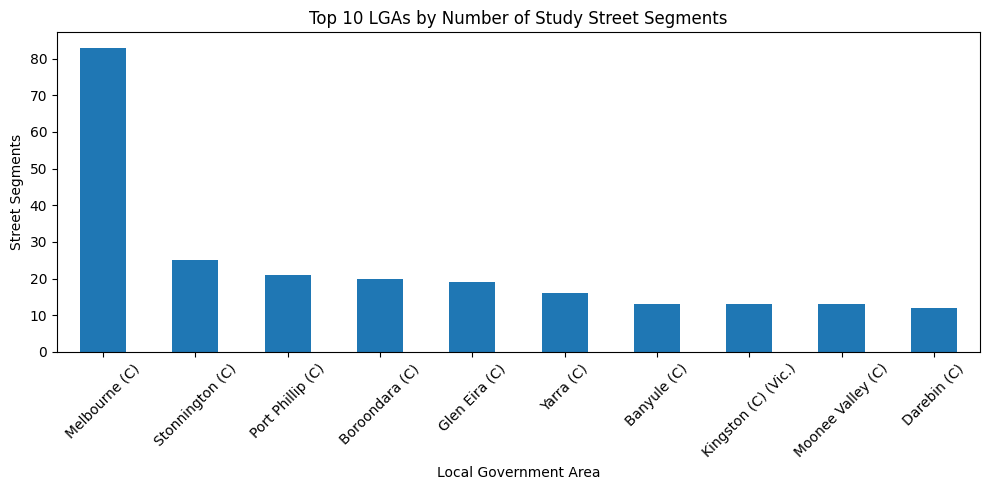

In [23]:
top_lga = (
    streets.groupby("lga")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_lga.plot(kind="bar")

plt.title("Top 10 LGAs by Number of Study Street Segments")
plt.xlabel("Local Government Area")
plt.ylabel("Street Segments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

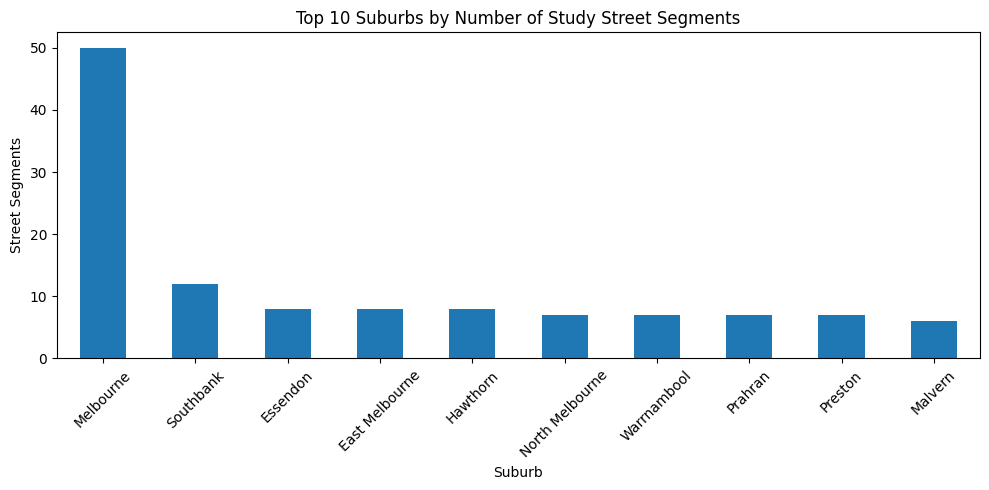

In [24]:
top_suburb = (
    streets.groupby("suburb")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_suburb.plot(kind="bar")

plt.title("Top 10 Suburbs by Number of Study Street Segments")
plt.xlabel("Suburb")
plt.ylabel("Street Segments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 15. Export outputs


In [25]:
output_dir = "/content/usia_outputs"
os.makedirs(output_dir, exist_ok=True)

quality_summary.to_csv(
    os.path.join(output_dir, "data_quality_summary.csv"), index=False
)
treatment_summary.to_csv(
    os.path.join(output_dir, "treatment_intervention_summary.csv"), index=False
)
suburb_summary.to_csv(
    os.path.join(output_dir, "suburb_summary.csv"), index=False
)
lga_summary.to_csv(
    os.path.join(output_dir, "lga_summary.csv"), index=False
)
priority_table.to_csv(
    os.path.join(output_dir, "team_b_priority_protected_bike_lanes.csv"), index=False
)
road_missing_summary.to_csv(
    os.path.join(output_dir, "road_network_missing_values_summary.csv"), index=False
)
unmatched_records.drop(columns="geometry", errors="ignore").to_csv(
    os.path.join(output_dir, "unmatched_study_area_records.csv"), index=False
)
study_areas_enriched.to_file(
    os.path.join(output_dir, "study_areas_enriched.gpkg"),
    driver="GPKG"
)

print("Created outputs:")
for filename in sorted(os.listdir(output_dir)):
    print(filename)


Created outputs:
data_quality_summary.csv
lga_summary.csv
road_network_missing_values_summary.csv
study_areas_enriched.gpkg
suburb_summary.csv
team_b_priority_protected_bike_lanes.csv
treatment_intervention_summary.csv
unmatched_study_area_records.csv


In [26]:
import shutil
from google.colab import files

archive_path = shutil.make_archive(
    "/content/Team_B_Sprint1_Analysis_Outputs",
    "zip",
    output_dir
)

files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Initial findings and limitations

### Initial findings

- The base street dataset contains **315 street segments**: **219 control** and **96 treatment** segments.
- The 96 treatment segments comprise **80 protected bike-lane**, **10 regional-reallocation**, and **6 pedestrian** segments.
- The buffered study-area dataset contains **316 records**. **315 records matched** the base street dataset using `street_segment_id`.
- One buffered record, **`street_segment_id = 3500`**, did not match the base treatment/control dataset. The same ID exists in the wider road-network file. It was retained for documentation but excluded from treatment/control maps.
- No duplicate rows, missing geometries or invalid geometries were found in the three spatial layers.
- A Team B priority subset of **64 protected bike-lane segments outside the CBD** was created.
- The statewide view shows that sites are distributed across metropolitan Melbourne and regional Victoria. Separate Melbourne and regional maps were created because individual street segments are difficult to interpret at the statewide scale.
- The road-network layer has missing descriptive attributes, primarily `length_km`, but these do not prevent the completed spatial joins or treatment/control analysis.

### Limitations

- The supplied spatial files define **where** the study occurs; they do not contain parking occupancy observations.
- Intervention dates are not included in these three files.
- Parking utilisation and before/after effects cannot yet be calculated.
- A valid later-stage analysis requires parking sensor or imagery-derived occupancy data, intervention dates, comparable observation periods, and appropriate control locations.
- The 64-segment priority subset is a technical shortlist, not a final selection of study sites.

### Next steps

The spatial analysis workflow developed in this notebook provides the foundation for subsequent Team B analyses.

Future work will integrate:

- SCATS Traffic Volume Data
- Bicycle Infrastructure Network (BIN)
- Pop-up Bike Lane installation dates
- Parking occupancy datasets
- Vicmap aerial imagery
- Google Earth historical imagery (if required)

The workflow can be extended to perform before-and-after parking utilisation analysis and traffic volume comparisons.


## 17. Conclusion

This notebook successfully validates and integrates the Infrastructure Victoria spatial datasets for Team B. It provides reproducible code for data-quality assessment, join validation, spatial visualisation, geographic summaries, priority-site identification and export of reusable outputs.

The workflow creates the spatial foundation for the project's core research question. It can be extended once parking occupancy, traffic-volume and intervention-date datasets become available.
